# Analiza struktur kombinatorycznych w słownikach językowych

Notebook analizuje wyniki generowane przez `natural_languages/examples/dictionary_stats.py`. Każda sekcja odpowiada jednemu wykresowi albo tabeli, tak aby można było później przenieść wyniki do raportu.

Porównujemy całe słowa, które są kwadratami, palindromami, kwadratami abelowymi, tangramami oraz przetasowanymi kwadratami. Dodatkowo osobno analizujemy anagramy, długości słów, alfabet i znaki diakrytyczne.

## 0. Przygotowanie danych

Jeśli katalog `results/` jest pusty, najpierw wygeneruj słowniki i statystyki. `make data` pobiera języki obsługiwane w `natural_languages.data.fetch`: `de`, `en`, `fr`, `pl`.

```bash
make data
for lang in de en fr pl; do
    uv run python -m natural_languages.examples.dictionary_stats --input data/raw/$lang.txt --language $lang
done
```

Notebook działa także dla dowolnego podzbioru języków, o ile istnieją pliki `results/<język>_summary.csv` i `results/<język>_hits.csv`.

In [25]:
from __future__ import annotations

import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass

    def display(value: object) -> None:
        print(value)

ROOT = Path.cwd()
if not (ROOT / 'natural_languages').exists() and (ROOT.parent / 'natural_languages').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from natural_languages.data import DataLoader, TextPreprocessor  # noqa: E402

RESULTS_DIR = ROOT / 'results'
RAW_DIR = ROOT / 'data' / 'raw'
FIGURES_DIR = ROOT / 'docs' / 'figures'
SAVE_FIGURES = False

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120

LANGUAGE_NAMES = {
    'de': 'niemiecki',
    'en': 'angielski',
    'fr': 'francuski',
    'pl': 'polski',
}
STRUCTURE_ORDER = [
    'square',
    'palindrome',
    'abelian_square',
    'tangram',
    'shuffled_square',
]
STRUCTURE_LABELS = {
    'square': 'kwadrat (ww)',
    'palindrome': 'palindrom',
    'abelian_square': 'kwadrat abelowy',
    'tangram': 'tangram',
    'shuffled_square': 'przetasowany kwadrat',
}
IS_COLUMNS = [f'is_{structure}' for structure in STRUCTURE_ORDER]


def language_label(language: str) -> str:
    return LANGUAGE_NAMES.get(language, language)


def note(text: str) -> None:
    display(Markdown(text))


def maybe_save(name: str | None) -> None:
    if SAVE_FIGURES and name:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / f'{name}.png', dpi=300, bbox_inches='tight')


def finish_plot(title: str, xlabel: str, ylabel: str, name: str | None = None) -> None:
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    maybe_save(name)
    plt.show()


def load_summary() -> pd.DataFrame:
    frames = []
    for path in sorted(RESULTS_DIR.glob('*_summary.csv')):
        frame = pd.read_csv(path)
        frame['source_file'] = path.name
        frames.append(frame)
    if not frames:
        return pd.DataFrame(
            columns=['language', 'n_words', 'structure', 'count', 'pct', 'longest_example', 'longest_len']
        )
    summary = pd.concat(frames, ignore_index=True)
    summary['language'] = summary['language'].astype(str)
    summary['language_label'] = summary['language'].map(language_label)
    summary = summary[summary['structure'].isin(STRUCTURE_ORDER)].copy()
    summary['structure'] = pd.Categorical(summary['structure'], categories=STRUCTURE_ORDER, ordered=True)
    summary['structure_label'] = summary['structure'].astype(str).map(STRUCTURE_LABELS)
    summary['n_words'] = pd.to_numeric(summary['n_words'], errors='coerce').fillna(0).astype(int)
    summary['count'] = pd.to_numeric(summary['count'], errors='coerce').fillna(0).astype(int)
    summary['pct'] = pd.to_numeric(summary['pct'], errors='coerce').fillna(0.0)
    summary['longest_len'] = pd.to_numeric(summary['longest_len'], errors='coerce').fillna(0).astype(int)
    return summary.sort_values(['structure', 'language']).reset_index(drop=True)


def load_hits() -> pd.DataFrame:
    frames = []
    for path in sorted(RESULTS_DIR.glob('*_hits.csv')):
        language = path.name.removesuffix('_hits.csv')
        frame = pd.read_csv(path)
        frame.insert(0, 'language', language)
        frames.append(frame)
    if not frames:
        return pd.DataFrame(columns=['language', 'word', 'length', *IS_COLUMNS])
    hits = pd.concat(frames, ignore_index=True)
    hits['language'] = hits['language'].astype(str)
    hits['language_label'] = hits['language'].map(language_label)
    hits['length'] = pd.to_numeric(hits['length'], errors='coerce').fillna(0).astype(int)
    for column in IS_COLUMNS:
        if column not in hits.columns:
            hits[column] = False
        hits[column] = hits[column].fillna(0).astype(bool)
    hits['n_structures'] = hits[IS_COLUMNS].sum(axis=1).astype(int)
    return hits


def load_raw_words(min_length: int = 2) -> pd.DataFrame:
    rows = []
    preprocessor = TextPreprocessor()
    for path in sorted(RAW_DIR.glob('*.txt')):
        language = path.stem
        raw_words = DataLoader(path).load_word_list()
        normalized = preprocessor.normalize_words(raw_words)
        words = [word for word in dict.fromkeys(normalized) if len(word) >= min_length]
        for word in words:
            rows.append(
                {
                    'language': language,
                    'language_label': language_label(language),
                    'word': word,
                    'length': len(word),
                    'has_diacritic': any(preprocessor.char_is_diacritic(char) for char in word),
                }
            )
    return pd.DataFrame(rows)


def build_full_words(raw_words: pd.DataFrame, hits: pd.DataFrame) -> pd.DataFrame:
    if raw_words.empty:
        full = hits.copy()
        if not full.empty:
            full['coverage'] = 'hits_only'
        return full
    flag_columns = ['language', 'word', *IS_COLUMNS]
    flags = hits[flag_columns].copy() if not hits.empty else pd.DataFrame(columns=flag_columns)
    full = raw_words.merge(flags, on=['language', 'word'], how='left')
    for column in IS_COLUMNS:
        full[column] = full[column].fillna(False).astype(bool)
    full['n_structures'] = full[IS_COLUMNS].sum(axis=1).astype(int)
    full['coverage'] = 'all_words'
    return full


def melt_hits(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()
    long = frame.melt(
        id_vars=['language', 'language_label', 'word', 'length'],
        value_vars=IS_COLUMNS,
        var_name='structure_column',
        value_name='matched',
    )
    long = long[long['matched']].copy()
    long['structure'] = long['structure_column'].str.removeprefix('is_')
    long['structure'] = pd.Categorical(long['structure'], categories=STRUCTURE_ORDER, ordered=True)
    long['structure_label'] = long['structure'].astype(str).map(STRUCTURE_LABELS)
    return long


def add_length_bins(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    max_len = int(frame['length'].max())
    edges = [1, 4, 7, 10, 13, 16, 20, 30, 50]
    edges = [edge for edge in edges if edge < max_len]
    edges = sorted(set([1, *edges, max_len]))
    if len(edges) < 2:
        edges = [1, max_len]
    labels = [
        f'{edges[i] + 1}-{edges[i + 1]}' if edges[i] + 1 != edges[i + 1] else str(edges[i + 1])
        for i in range(len(edges) - 1)
    ]
    out = frame.copy()
    out['length_bin'] = pd.cut(out['length'], bins=edges, labels=labels, include_lowest=True)
    return out


def compute_anagram_tables(words: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    stats_rows = []
    example_rows = []
    if words.empty:
        return pd.DataFrame(), pd.DataFrame()
    for (language, language_name), group in words.groupby(['language', 'language_label']):
        buckets: dict[tuple[tuple[str, int], ...], list[str]] = {}
        for word in group['word']:
            key = tuple(sorted(Counter(word).items()))
            buckets.setdefault(key, []).append(word)
        anagram_groups = [sorted(values) for values in buckets.values() if len(values) >= 2]
        words_in_groups = sum(len(values) for values in anagram_groups)
        largest_size = max((len(values) for values in anagram_groups), default=0)
        stats_rows.append(
            {
                'language': language,
                'język': language_name,
                'liczba grup': len(anagram_groups),
                'słów w grupach': words_in_groups,
                '% słów w grupach': 100.0 * words_in_groups / len(group) if len(group) else 0.0,
                'największa grupa': largest_size,
            }
        )
        for rank, values in enumerate(sorted(anagram_groups, key=lambda item: (-len(item), item[0]))[:5], start=1):
            example_rows.append(
                {
                    'język': language_name,
                    'ranga': rank,
                    'rozmiar grupy': len(values),
                    'przykłady': ', '.join(values[:20]),
                }
            )
    return pd.DataFrame(stats_rows), pd.DataFrame(example_rows)


summary = load_summary()
hits = load_hits()
raw_words = load_raw_words()
full_words = build_full_words(raw_words, hits)
long_hits = melt_hits(hits)

if summary.empty:
    note('**Brak wyników w `results/`.** Wykonaj komendy z sekcji 0, a potem uruchom notebook ponownie.')
else:
    note(
        f"Wczytano statystyki dla {summary['language'].nunique()} języków, "
        f'{len(hits):,} trafień struktur i {len(raw_words):,} słów surowych po normalizacji.'.replace(',', ' ')
    )


Wczytano statystyki dla 4 języków  633 292 trafień struktur i 634 033 słów surowych po normalizacji.

## 1. Zakres danych: liczba słów w językach

Tabela i wykres pokazują, jak duże są porównywane słowniki po normalizacji i odfiltrowaniu słów krótszych niż dwa znaki. To ważne, bo większy słownik naturalnie zwiększa szansę znalezienia rzadkich struktur.

,language,język,liczba słów,średnia_długość,mediana_długości
0,pl,polski,343038,10.51,10.0
1,de,niemiecki,163739,12.03,12.0
2,fr,francuski,79090,9.22,9.0
3,en,angielski,48166,7.83,8.0


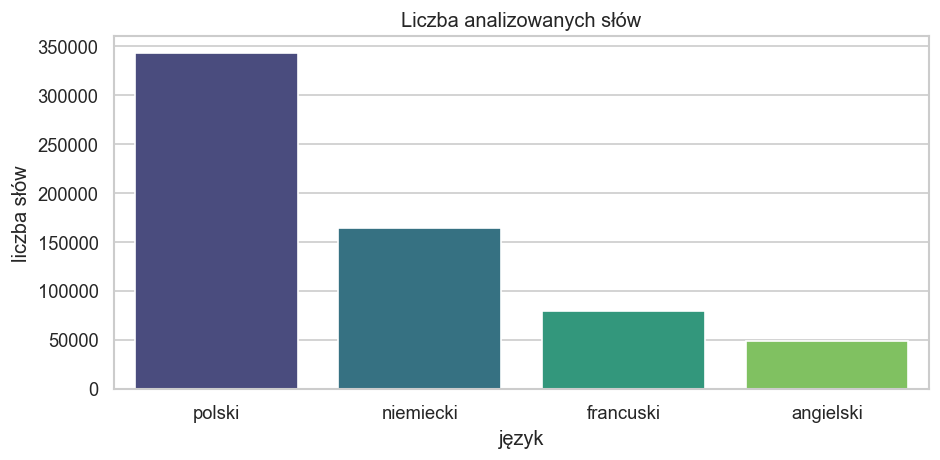

In [26]:
if summary.empty:
    note('Brak danych do sekcji 1.')
else:
    scope = (
        summary.groupby(['language', 'language_label'], observed=True)
        .agg(n_words=('n_words', 'max'))
        .reset_index()
        .sort_values('n_words', ascending=False)
    )
    if not raw_words.empty:
        raw_scope = (
            raw_words.groupby('language')
            .agg(średnia_długość=('length', 'mean'), mediana_długości=('length', 'median'))
            .reset_index()
        )
        scope = scope.merge(raw_scope, on='language', how='left')
    scope_display = scope.rename(columns={'language_label': 'język', 'n_words': 'liczba słów'})
    display(scope_display.round({'średnia_długość': 2, 'mediana_długości': 1}))

    plt.figure(figsize=(8, 4))
    sns.barplot(data=scope, x='language_label', y='n_words', hue='language_label', palette='viridis', legend=False)
    finish_plot('Liczba analizowanych słów', 'język', 'liczba słów', '01_scope_words')


## 2. Rozkład długości słów

Rozkład długości wpływa na każdą badaną strukturę: palindromy i kwadraty całosłowowe wymagają silnych symetrii, a detekcja przetasowanych kwadratów jest ograniczona maksymalną długością.

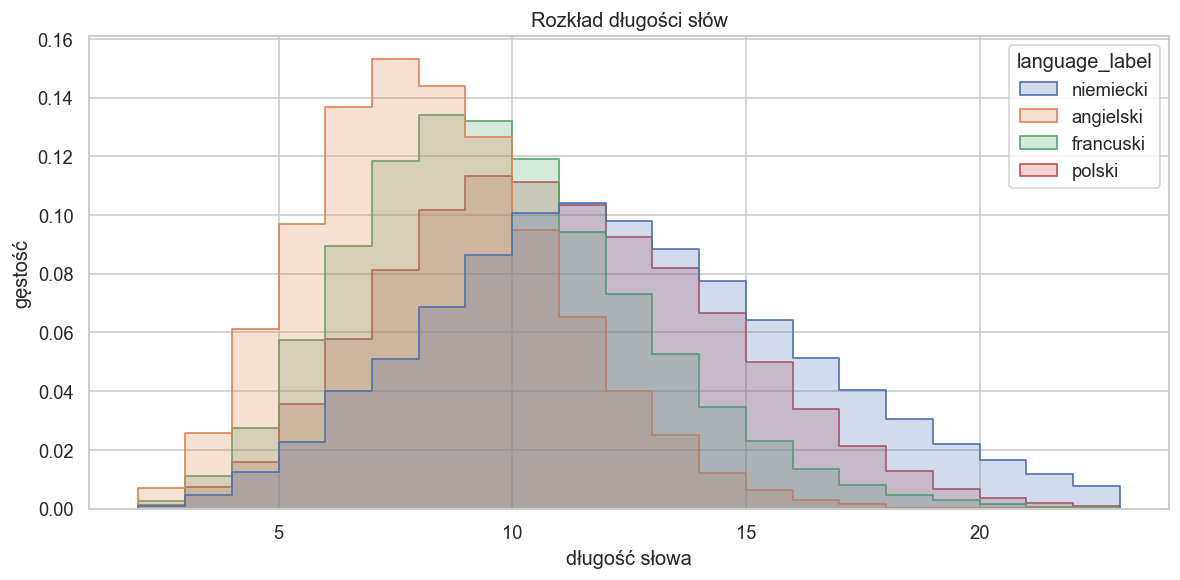

In [27]:
if raw_words.empty:
    note('Brak `data/raw/*.txt`; sekcja długości wymaga słowników wejściowych.')
else:
    max_len = int(raw_words['length'].quantile(0.995))
    plot_data = raw_words[raw_words['length'] <= max_len]
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=plot_data,
        x='length',
        hue='language_label',
        bins=range(2, max_len + 2),
        stat='density',
        common_norm=False,
        element='step',
    )
    finish_plot('Rozkład długości słów', 'długość słowa', 'gęstość', '02_length_distribution')


## 3. Kwantyle długości słów

Tabela zbiera podstawowe parametry długości słów. Przy interpretacji różnic między językami warto oddzielić efekt struktury języka od efektu rozmiaru i długości słownika.

In [28]:
if raw_words.empty:
    note('Brak danych długości.')
else:
    quantiles = raw_words.groupby('language_label')['length'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).unstack()
    quantiles.columns = ['p10', 'p25', 'p50', 'p75', 'p90', 'p95']
    length_table = raw_words.groupby('language_label').agg(
        liczba_słów=('word', 'count'),
        średnia=('length', 'mean'),
        minimum=('length', 'min'),
        maksimum=('length', 'max'),
    )
    length_table = length_table.join(quantiles).reset_index().rename(columns={'language_label': 'język'})
    display(length_table.round({'średnia': 2, 'p10': 0, 'p25': 0, 'p50': 0, 'p75': 0, 'p90': 0, 'p95': 0}))


,język,liczba_słów,średnia,minimum,maksimum,p10,p25,p50,p75,p90,p95
0,angielski,48166,7.83,2,23,5.0,6.0,8.0,9.0,11.0,12.0
1,francuski,79090,9.22,2,32,6.0,7.0,9.0,11.0,13.0,15.0
2,niemiecki,163739,12.03,2,67,7.0,9.0,12.0,15.0,18.0,19.0
3,polski,343038,10.51,2,33,6.0,8.0,10.0,13.0,15.0,16.0


## 4. Liczebność struktur

Wykres porównuje bezwzględne liczby słów spełniających każdą własność. To pokazuje skalę zjawiska, ale samo w sobie nie wystarcza do porównania języków o różnych rozmiarach słownika.

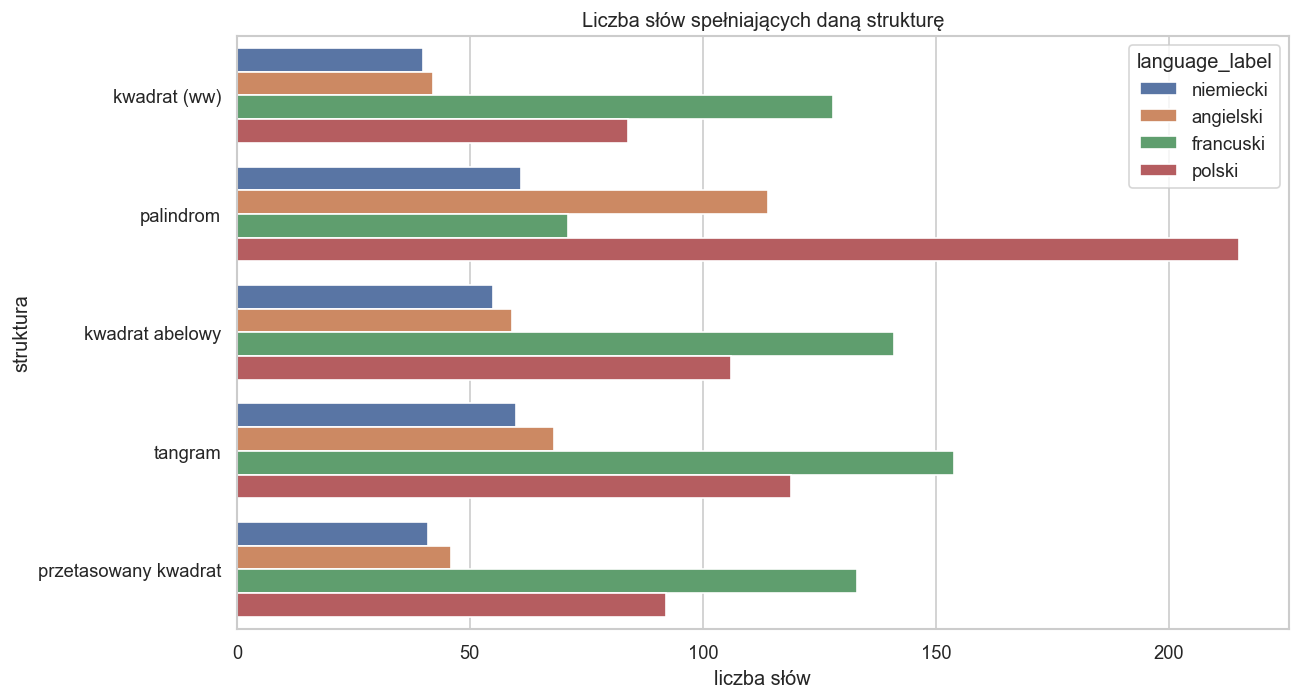

In [29]:
if summary.empty:
    note('Brak danych struktur.')
else:
    plt.figure(figsize=(11, 6))
    sns.barplot(data=summary, y='structure_label', x='count', hue='language_label')
    finish_plot('Liczba słów spełniających daną strukturę', 'liczba słów', 'struktura', '04_structure_counts')


## 5. Udział struktur w słowniku

Procent słownika jest podstawową miarą do porównywania języków. Redukuje wpływ różnej liczby haseł, choć nadal pozostaje zależny od rozkładu długości i typu słownika.

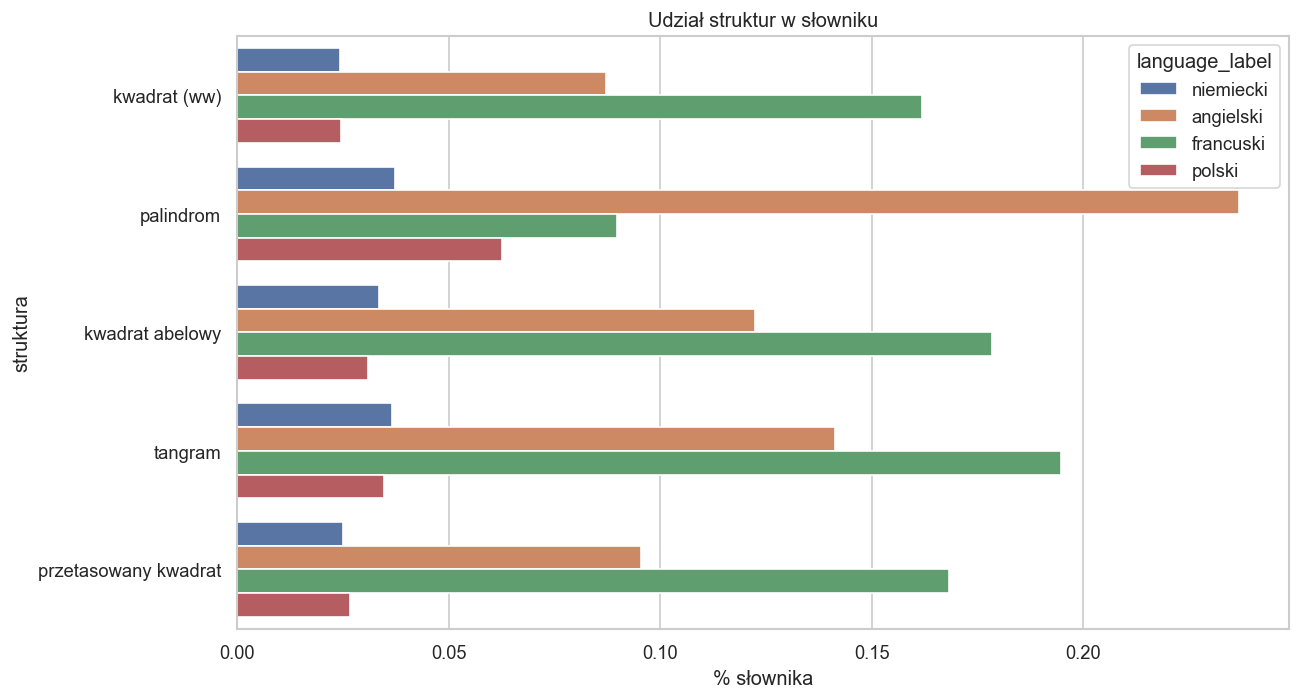

In [30]:
if summary.empty:
    note('Brak danych procentowych.')
else:
    plt.figure(figsize=(11, 6))
    sns.barplot(data=summary, y='structure_label', x='pct', hue='language_label')
    finish_plot('Udział struktur w słowniku', '% słownika', 'struktura', '05_structure_percentages')


## 6. Heatmapa język × struktura

Heatmapa ułatwia szybkie znalezienie kontrastów: jasne pola oznaczają struktury relatywnie częstsze w danym języku.

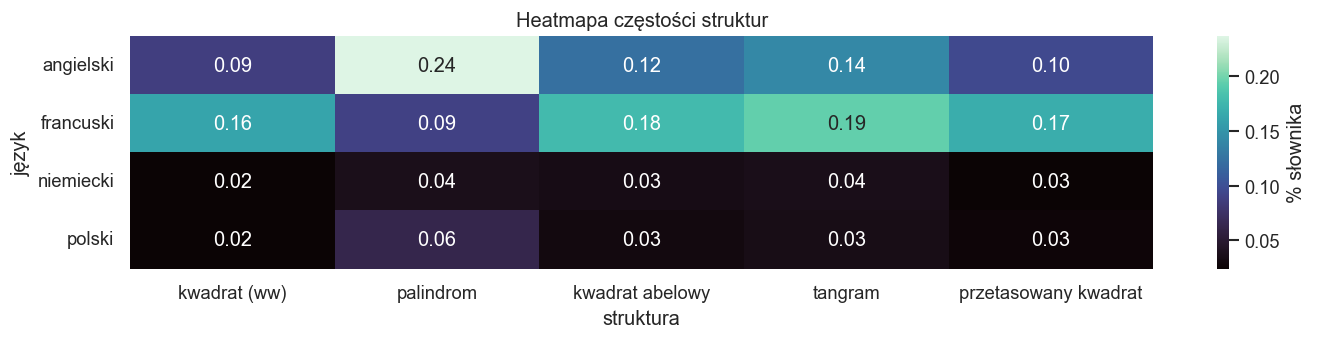

In [31]:
if summary.empty:
    note('Brak danych do heatmapy.')
else:
    heatmap_data = summary.pivot_table(
        index='language_label',
        columns='structure_label',
        values='pct',
        observed=True,
    )
    ordered_columns = [STRUCTURE_LABELS[item] for item in STRUCTURE_ORDER]
    heatmap_data = heatmap_data.reindex(columns=ordered_columns)
    plt.figure(figsize=(12, max(3, 0.7 * len(heatmap_data))))
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='mako', cbar_kws={'label': '% słownika'})
    finish_plot('Heatmapa częstości struktur', 'struktura', 'język', '06_structure_heatmap')


## 7. Ranking języków dla każdej struktury

Tabela pokazuje, który język ma największy udział danej struktury i jak duża jest różnica między skrajnymi językami.

In [32]:
if summary.empty:
    note('Brak danych rankingowych.')
else:
    rows = []
    for structure in STRUCTURE_ORDER:
        group = summary[summary['structure'].astype(str) == structure].sort_values('pct', ascending=False)
        if group.empty:
            continue
        leader = group.iloc[0]
        rows.append(
            {
                'struktura': STRUCTURE_LABELS[structure],
                'lider': leader['language_label'],
                'lider %': leader['pct'],
                'różnica max-min pp': group['pct'].max() - group['pct'].min(),
                'ranking': ' > '.join(f'{row.language_label} ({row.pct:.3f}%)' for row in group.itertuples()),
            }
        )
    ranking = pd.DataFrame(rows)
    display(ranking.round({'lider %': 4, 'różnica max-min pp': 4}))


,struktura,lider,lider %,różnica max-min pp,ranking
0,kwadrat (ww),francuski,0.1618,0.1374,francuski (0.162%) > angielski (0.087%) > pols...
1,palindrom,angielski,0.2367,0.1994,angielski (0.237%) > francuski (0.090%) > pols...
2,kwadrat abelowy,francuski,0.1783,0.1474,francuski (0.178%) > angielski (0.122%) > niem...
3,tangram,francuski,0.1947,0.1600,francuski (0.195%) > angielski (0.141%) > niem...
4,przetasowany kwadrat,francuski,0.1682,0.1432,francuski (0.168%) > angielski (0.096%) > pols...


## 9. Najdłuższe przykłady struktur

Tabela wskazuje rekordowe przykłady zapisane w plikach `*_summary.csv`. To dobry materiał do raportu, bo pokazuje konkretne słowa stojące za statystykami.

In [34]:
if summary.empty:
    note('Brak rekordowych przykładów.')
else:
    longest = summary[['language_label', 'structure_label', 'longest_example', 'longest_len']].copy()
    longest = longest.rename(
        columns={
            'language_label': 'język',
            'structure_label': 'struktura',
            'longest_example': 'najdłuższy przykład',
            'longest_len': 'długość',
        }
    )
    display(longest.sort_values(['struktura', 'długość'], ascending=[True, False]))


,język,struktura,najdłuższy przykład,długość
0,niemiecki,kwadrat (ww),computercomputer,16
2,francuski,kwadrat (ww),gagnantgagnant,14
1,angielski,kwadrat (ww),khoikhoi,8
3,polski,kwadrat (ww),dziadzia,8
8,niemiecki,kwadrat abelowy,computercomputer,16
10,francuski,kwadrat abelowy,gagnantgagnant,14
11,polski,kwadrat abelowy,niedziadzienia,14
9,angielski,kwadrat abelowy,khoikhoi,8
4,niemiecki,palindrom,reliefpfeiler,13
5,angielski,palindrom,malayalam,9


## 10. Top przykłady z katalogu trafień

Ta tabela rozwija rekordy: dla każdej struktury i języka pokazuje kilka najdłuższych trafień z `*_hits.csv`.

In [35]:
if long_hits.empty:
    note('Brak `*_hits.csv` albo brak trafień.')
else:
    top_rows = []
    for (
        language_name,
        structure_name,
    ), group in long_hits.groupby(['language_label', 'structure_label'], observed=True):
        examples = group.sort_values(['length', 'word'], ascending=[False, True]).head(8)
        top_rows.append(
            {
                'język': language_name,
                'struktura': structure_name,
                'najdłuższe trafienia': ', '.join(f'{row.word} ({row.length})' for row in examples.itertuples()),
            }
        )
    display(pd.DataFrame(top_rows).sort_values(['struktura', 'język']))


,język,struktura,najdłuższe trafienia
0,angielski,kwadrat (ww),"beriberi (8), couscous (8), froufrou (8), khoi..."
5,francuski,kwadrat (ww),"gagnantgagnant (14), gouzisgouzis (12), moitié..."
10,niemiecki,kwadrat (ww),"computercomputer (16), igittigitt (10), killek..."
15,polski,kwadrat (ww),"dziadzia (8), froufrou (8), karakara (8), kolo..."
1,angielski,kwadrat abelowy,"beriberi (8), bilabial (8), couscous (8), frou..."
6,francuski,kwadrat abelowy,"gagnantgagnant (14), gouzisgouzis (12), moitié..."
11,niemiecki,kwadrat abelowy,"computercomputer (16), igittigitt (10), killek..."
16,polski,kwadrat abelowy,"niedziadzienia (14), kryptoportyk (12), niecha..."
2,angielski,palindrom,"malayalam (9), hannah (6), redder (6), civic (..."
7,francuski,palindrom,"malayalam (9), ressasser (9), retâter (7), han..."


## 11. Liczba trafień względem długości słowa

Wykres pokazuje, przy jakich długościach pojawia się najwięcej słów spełniających co najmniej jedną badaną własność. Nie jest to jeszcze częstość warunkowa, bo mianownik zależy od liczby wszystkich słów danej długości.

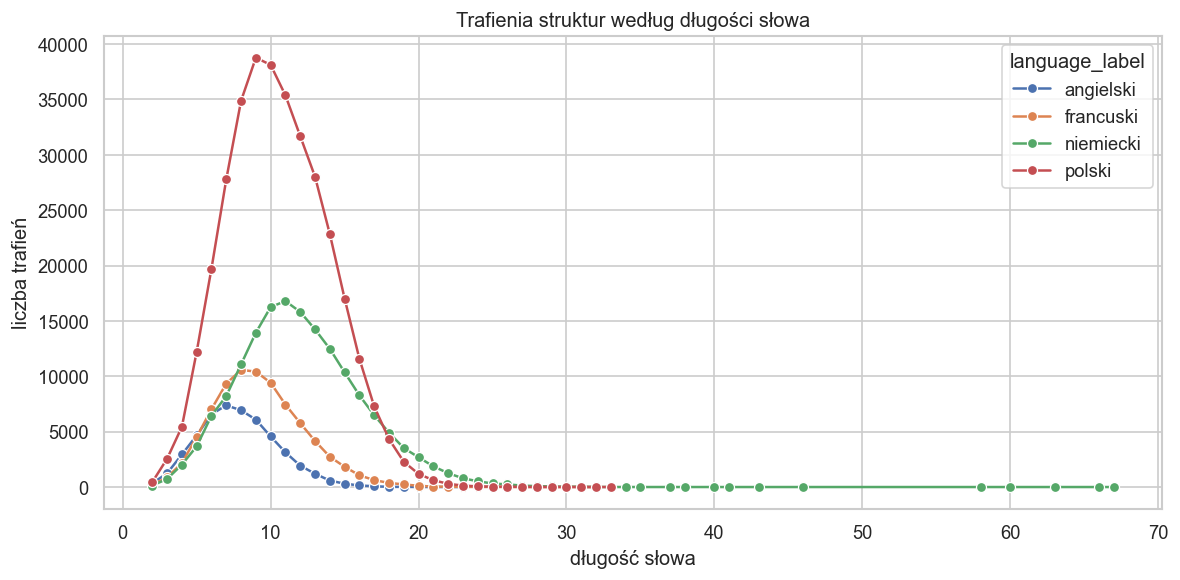

In [36]:
if hits.empty:
    note('Brak katalogu trafień.')
else:
    hit_counts = hits.groupby(['language_label', 'length']).size().reset_index(name='liczba trafień')
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=hit_counts, x='length', y='liczba trafień', hue='language_label', marker='o')
    finish_plot('Trafienia struktur według długości słowa', 'długość słowa', 'liczba trafień', '12_hits_by_length')


## 12. Profile długości dla poszczególnych struktur

Facetowany wykres rozdziela trafienia według struktury. Dzięki temu widać, czy dana własność koncentruje się na krótkich słowach, czy pojawia się także dla dłuższych haseł.

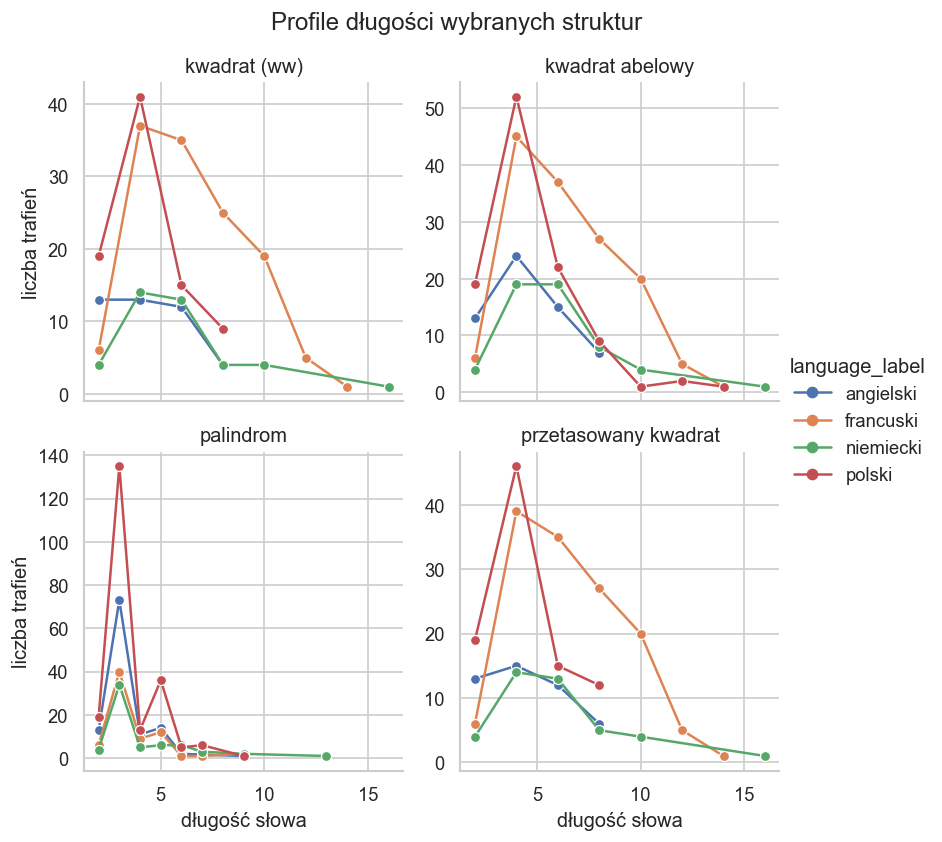

In [37]:
if long_hits.empty:
    note('Brak danych do profili długości.')
else:
    profile = (
        long_hits.groupby(['language_label', 'structure_label', 'length'], observed=True)
        .size()
        .reset_index(name='liczba trafień')
    )
    selected_structures = ['square', 'palindrome', 'abelian_square', 'shuffled_square']
    selected_labels = [STRUCTURE_LABELS[item] for item in selected_structures]
    selected = profile[profile['structure_label'].isin(selected_labels)]
    grid = sns.relplot(
        data=selected,
        x='length',
        y='liczba trafień',
        hue='language_label',
        col='structure_label',
        col_wrap=2,
        kind='line',
        marker='o',
        facet_kws={'sharey': False},
        height=3.4,
    )
    grid.set_axis_labels('długość słowa', 'liczba trafień')
    grid.set_titles('{col_name}')
    grid.figure.suptitle('Profile długości wybranych struktur', y=1.03)
    maybe_save('13_structure_length_profiles')
    plt.show()


## 13. Częstość struktur w przedziałach długości

Tutaj mianownikiem są wszystkie słowa z danego przedziału długości. To pomaga oddzielić realną częstość struktury od samego faktu, że słów średniej długości jest zwykle najwięcej.

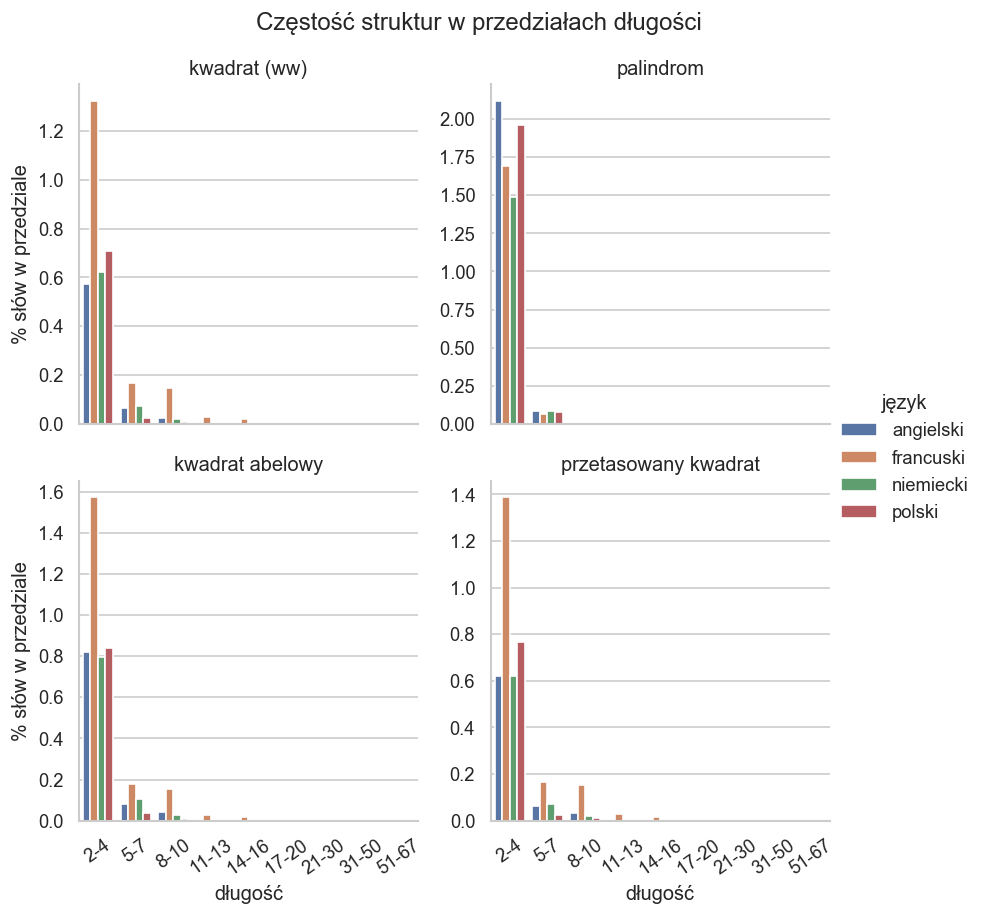

In [38]:
if full_words.empty or full_words['coverage'].eq('hits_only').all():
    note('Sekcja wymaga `data/raw/*.txt`, żeby znać mianownik dla każdej długości.')
else:
    binned = add_length_bins(full_words)
    selected_structures = ['square', 'palindrome', 'abelian_square', 'shuffled_square']
    rows = []
    for (language_name, length_bin), group in binned.groupby(['language_label', 'length_bin'], observed=True):
        total = len(group)
        for structure in selected_structures:
            rows.append(
                {
                    'język': language_name,
                    'przedział długości': str(length_bin),
                    'struktura': STRUCTURE_LABELS[structure],
                    'częstość %': 100.0 * group[f'is_{structure}'].sum() / total if total else 0.0,
                }
            )
    rates_by_bin = pd.DataFrame(rows)
    grid = sns.catplot(
        data=rates_by_bin,
        x='przedział długości',
        y='częstość %',
        hue='język',
        col='struktura',
        col_wrap=2,
        kind='bar',
        sharey=False,
        height=3.6,
    )
    grid.set_axis_labels('długość', '% słów w przedziale')
    grid.set_titles('{col_name}')
    for axis in grid.axes.flat:
        axis.tick_params(axis='x', rotation=35)
    grid.figure.suptitle('Częstość struktur w przedziałach długości', y=1.03)
    maybe_save('14_rates_by_length_bin')
    plt.show()


## 14. Współwystępowanie struktur

Macierz pokazuje, ile słów jednocześnie spełnia pary własności. Przekątna odpowiada liczbie słów spełniających daną własność.

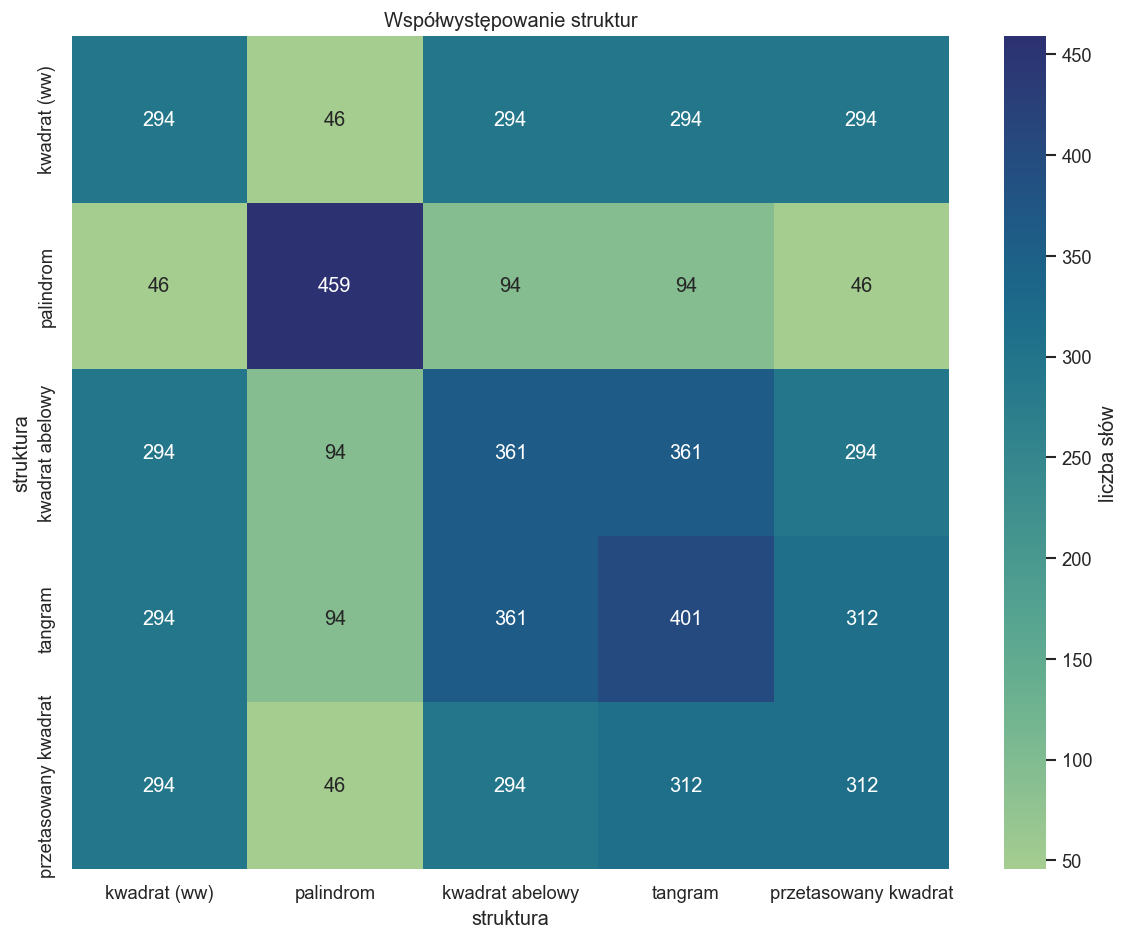

In [39]:
base = full_words if not full_words.empty else hits
if base.empty:
    note('Brak danych do macierzy współwystępowania.')
else:
    labels = [STRUCTURE_LABELS[item] for item in STRUCTURE_ORDER]
    matrix = pd.DataFrame(0, index=labels, columns=labels)
    for left in STRUCTURE_ORDER:
        for right in STRUCTURE_ORDER:
            left_label = STRUCTURE_LABELS[left]
            right_label = STRUCTURE_LABELS[right]
            both = base[f'is_{left}'] & base[f'is_{right}']
            matrix.loc[left_label, right_label] = int(both.sum())
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='crest', cbar_kws={'label': 'liczba słów'})
    finish_plot('Współwystępowanie struktur', 'struktura', 'struktura', '15_structure_cooccurrence')


## 15. Ile struktur naraz spełnia jedno słowo

Rozkład liczby spełnionych własności pokazuje, czy trafienia są izolowane, czy wiele struktur koncentruje się w tych samych słowach.

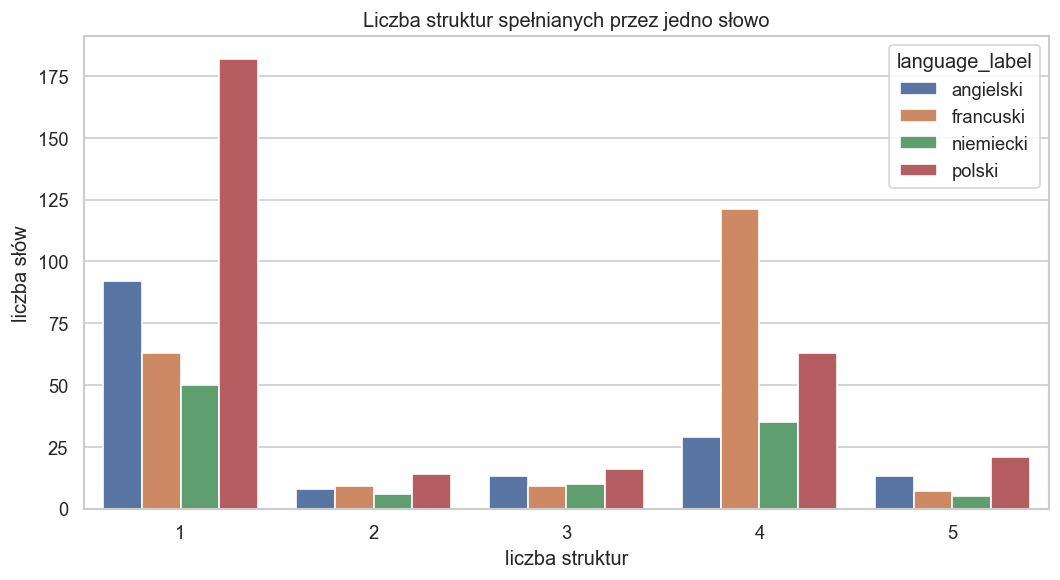

In [ ]:
base = full_words if not full_words.empty else hits
if base.empty:
    note('Brak danych do rozkładu liczby struktur.')
else:
    multiplicity = base.groupby(['language_label', 'n_structures']).size().reset_index(name='liczba słów')
    multiplicity_table = (
        multiplicity.pivot(index='n_structures', columns='language_label', values='liczba słów')
        .fillna(0)
        .astype(int)
    )

    multiplicity = multiplicity[multiplicity['n_structures'] > 0].copy()

    plt.figure(figsize=(9, 5))
    sns.barplot(data=multiplicity, x='n_structures', y='liczba słów', hue='language_label')
    finish_plot(
        'Liczba struktur spełnianych przez jedno słowo',
        'liczba struktur',
        'liczba słów',
        '16_structure_multiplicity',
    )


## 16. Anagramy: skala zjawiska

Anagramy nie są zapisywane przez `dictionary_stats.py` do osobnego CSV, więc tutaj liczymy grupy bezpośrednio ze znormalizowanych słowników wejściowych.

,language,język,liczba grup,słów w grupach,% słów w grupach,największa grupa
0,de,niemiecki,3340,7192,4.392,7
1,en,angielski,2613,5840,12.125,6
2,fr,francuski,3536,7814,9.880,7
3,pl,polski,16351,36064,10.513,10


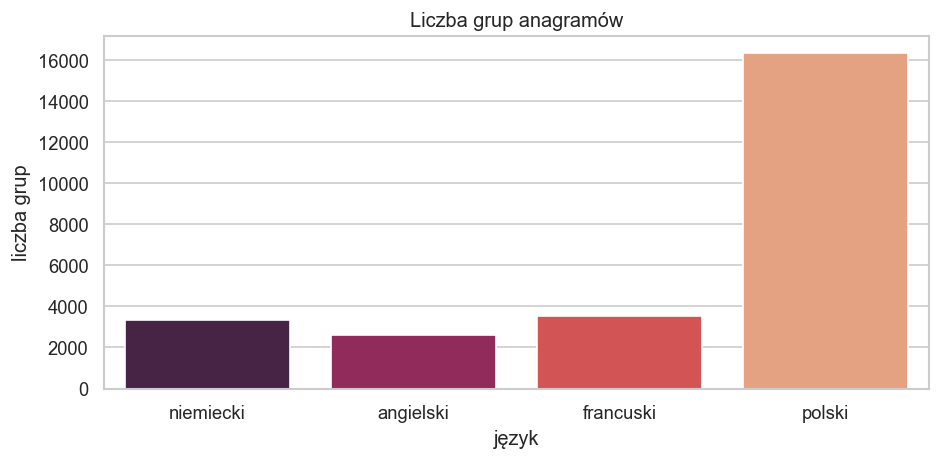

In [41]:
if raw_words.empty:
    note('Brak `data/raw/*.txt`; analiza anagramów wymaga słowników wejściowych.')
else:
    anagram_stats, largest_anagrams = compute_anagram_tables(raw_words)
    display(anagram_stats.round({'% słów w grupach': 3}))
    plt.figure(figsize=(8, 4))
    sns.barplot(data=anagram_stats, x='język', y='liczba grup', hue='język', palette='rocket', legend=False)
    finish_plot('Liczba grup anagramów', 'język', 'liczba grup', '17_anagram_groups')


## 17. Największe grupy anagramów

Największe grupy są użyteczne jakościowo: pozwalają sprawdzić, czy wyniki wynikają z realnych słów, wariantów zapisu, form skrótowych albo artefaktów słownika.

In [42]:
if raw_words.empty:
    note('Brak danych do grup anagramów.')
else:
    anagram_stats, largest_anagrams = compute_anagram_tables(raw_words)
    display(largest_anagrams)


,język,ranga,rozmiar grupy,przykłady
0,niemiecki,1,7,"berti, breit, briet, brite, tiber, treib, trieb"
1,niemiecki,2,7,"einser, eisern, eisner, reisen, riesen, serien..."
2,niemiecki,3,6,"eifern, feiern, ferien, fieren, freien, reifen"
3,niemiecki,4,6,"ilse, isel, lies, lise, seil, siel"
4,niemiecki,5,5,"algen, angel, galen, lagen, nagel"
5,angielski,1,6,"alger, elgar, glare, lager, large, regal"
6,angielski,2,6,"darin, dinar, drain, indra, nadir, randi"
7,angielski,3,6,"ergo, goer, gore, ogre, oreg, roeg"
8,angielski,4,6,"leapt, lepta, patel, petal, plate, pleat"
9,angielski,5,6,"least, slate, stael, stale, steal, tesla"


## 18. Alfabet i znaki diakrytyczne

Rozmiar alfabetu i udział słów z diakrytykami wpływają na prawdopodobieństwo powtórzeń liter. W projekcie znaki z diakrytykami są traktowane jako osobne symbole.

,language,język,rozmiar alfabetu,% słów z diakrytykiem,alfabet
0,de,niemiecki,36,22.97,abcdefghijklmnopqrstuvwxyzßàâäçèéêöü
1,en,angielski,26,0.00,abcdefghijklmnopqrstuvwxyz
2,fr,francuski,48,30.00,abcdefghijklmnopqrstuvwxyzàâäæçèéêëîïóôöùûüÿćńœś
3,pl,polski,43,40.15,abcdefghijklmnopqrstuvwxyzâäçéëóôöüąćęłńśźż


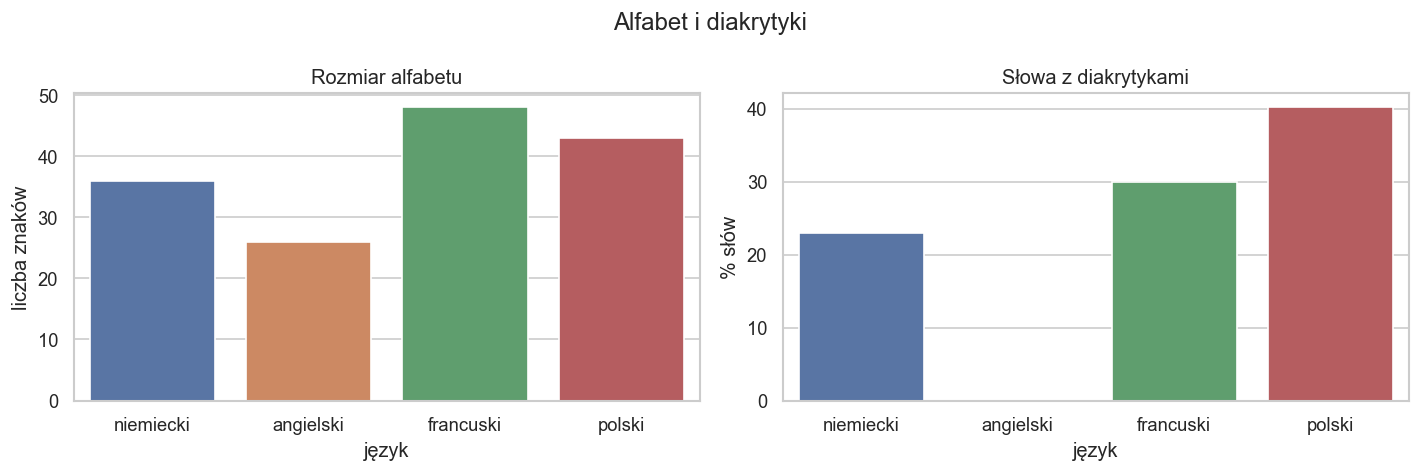

In [43]:
if raw_words.empty:
    note('Brak danych alfabetu.')
else:
    alphabet_rows = []
    for (language, language_name), group in raw_words.groupby(['language', 'language_label']):
        counter = Counter(''.join(group['word']))
        alphabet = ''.join(sorted(counter))
        alphabet_rows.append(
            {
                'language': language,
                'język': language_name,
                'rozmiar alfabetu': len(counter),
                '% słów z diakrytykiem': 100.0 * group['has_diacritic'].mean(),
                'alfabet': alphabet,
            }
        )
    alphabet_table = pd.DataFrame(alphabet_rows)
    display(alphabet_table.round({'% słów z diakrytykiem': 2}))

    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=alphabet_table, x='język', y='rozmiar alfabetu', hue='język', legend=False, ax=axes[0])
    axes[0].set_title('Rozmiar alfabetu')
    axes[0].set_xlabel('język')
    axes[0].set_ylabel('liczba znaków')
    sns.barplot(data=alphabet_table, x='język', y='% słów z diakrytykiem', hue='język', legend=False, ax=axes[1])
    axes[1].set_title('Słowa z diakrytykami')
    axes[1].set_xlabel('język')
    axes[1].set_ylabel('% słów')
    figure.suptitle('Alfabet i diakrytyki')
    plt.tight_layout()
    maybe_save('19_alphabet_diacritics')
    plt.show()


## 19. Najczęstsze litery

Porównanie najczęstszych liter pomaga interpretować struktury abelowe i anagramy, bo zależą one od histogramów liter, a nie od dokładnej kolejności znaków.

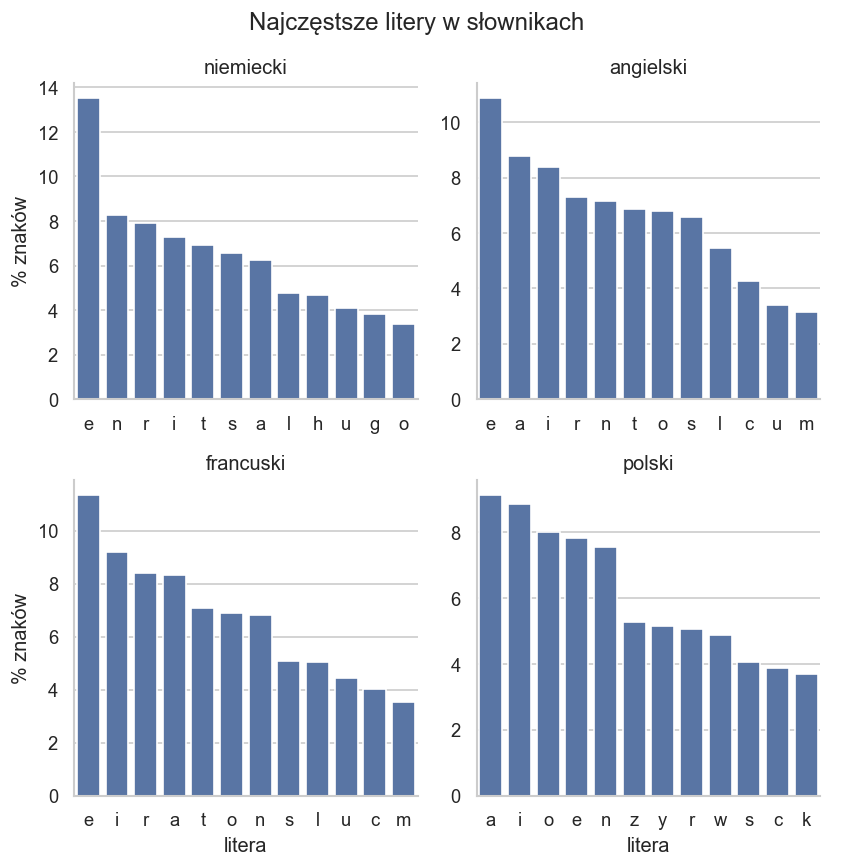

In [44]:
if raw_words.empty:
    note('Brak danych do częstości liter.')
else:
    char_rows = []
    for (language, language_name), group in raw_words.groupby(['language', 'language_label']):
        counter = Counter(''.join(group['word']))
        total = sum(counter.values())
        for char, count in counter.most_common(12):
            char_rows.append(
                {
                    'język': language_name,
                    'litera': char,
                    'liczba': count,
                    'częstość %': 100.0 * count / total,
                }
            )
    char_frequency = pd.DataFrame(char_rows)
    grid = sns.catplot(
        data=char_frequency,
        x='litera',
        y='częstość %',
        col='język',
        col_wrap=2,
        kind='bar',
        sharex=False,
        sharey=False,
        height=3.5,
        color='#4c72b0',
    )
    grid.set_axis_labels('litera', '% znaków')
    grid.set_titles('{col_name}')
    grid.figure.suptitle('Najczęstsze litery w słownikach', y=1.03)
    maybe_save('20_top_letters')
    plt.show()


## 20. Automatyczne obserwacje do raportu

Ta tabela zbiera zdania startowe do części opisowej. Należy je potraktować jako szkic: po obejrzeniu konkretnych słów warto dopisać interpretację językoznawczą i ograniczenia danych.

In [45]:
if summary.empty:
    note('Brak danych do obserwacji.')
else:
    observations = []
    for structure in STRUCTURE_ORDER:
        group = summary[summary['structure'].astype(str) == structure].sort_values('pct', ascending=False)
        if len(group) < 2:
            continue
        leader = group.iloc[0]
        tail = group.iloc[-1]
        observations.append(
            {
                'temat': STRUCTURE_LABELS[structure],
                'obserwacja': (
                    f"Najwyższy udział struktury '{STRUCTURE_LABELS[structure]}' ma język {leader['language_label']} "
                    f"({leader['pct']:.4f}%), a najniższy {tail['language_label']} ({tail['pct']:.4f}%)."
                ),
            }
        )
    if not raw_words.empty:
        mean_lengths = raw_words.groupby('language_label')['length'].mean().sort_values(ascending=False)
        observations.append(
            {
                'temat': 'długość słów',
                'obserwacja': (
                    f'Najwyższą średnią długość ma język {mean_lengths.index[0]} ({mean_lengths.iloc[0]:.2f}), '
                    f'a najniższą {mean_lengths.index[-1]} ({mean_lengths.iloc[-1]:.2f}).'
                ),
            }
        )
    display(pd.DataFrame(observations))


,temat,obserwacja
0,kwadrat (ww),Najwyższy udział struktury 'kwadrat (ww)' ma j...
1,palindrom,Najwyższy udział struktury 'palindrom' ma języ...
2,kwadrat abelowy,Najwyższy udział struktury 'kwadrat abelowy' m...
3,tangram,Najwyższy udział struktury 'tangram' ma język ...
4,przetasowany kwadrat,Najwyższy udział struktury 'przetasowany kwadr...
5,długość słów,Najwyższą średnią długość ma język niemiecki (...


## 21. Szkic akapitów końcowych

Tabela poniżej porządkuje materiał na raport: osobno metodologia, wyniki ilościowe, przykłady jakościowe i ograniczenia.

In [46]:
report_outline = pd.DataFrame(
    [
        {
            'część raportu': 'metodologia',
            'treść do rozwinięcia': (
                'Słowniki pochodzą z hunspell LibreOffice, są normalizowane identycznym pipeline: '
                'małe litery, usunięcie interpunkcji, diakrytyki jako osobne symbole.'
            ),
        },
        {
            'część raportu': 'porównanie ilościowe',
            'treść do rozwinięcia': (
                'Główne porównanie opiera się na procencie słów spełniających daną strukturę, '
                'nie na surowych liczbach trafień.'
            ),
        },
        {
            'część raportu': 'wpływ długości',
            'treść do rozwinięcia': (
                'Różnice w rozkładzie długości słów należy traktować jako potencjalny '
                'czynnik zakłócający, szczególnie dla struktur zależnych od symetrii i parzystości.'
            ),
        },
        {
            'część raportu': 'przykłady',
            'treść do rozwinięcia': (
                'Najdłuższe przykłady i największe grupy anagramów warto sprawdzić ręcznie '
                'pod kątem artefaktów słownikowych.'
            ),
        },
        {
            'część raportu': 'ograniczenia',
            'treść do rozwinięcia': (
                'Przetasowane kwadraty są liczone tylko do limitu długości ustawionego w skrypcie, '
                'więc nie są bezpośrednio porównywalne z własnościami liczonymi dla wszystkich słów.'
            ),
        },
    ]
)
display(report_outline)


,część raportu,treść do rozwinięcia
0,metodologia,"Słowniki pochodzą z hunspell LibreOffice, są n..."
1,porównanie ilościowe,Główne porównanie opiera się na procencie słów...
2,wpływ długości,Różnice w rozkładzie długości słów należy trak...
3,przykłady,Najdłuższe przykłady i największe grupy anagra...
4,ograniczenia,Przetasowane kwadraty są liczone tylko do limi...
